## Practice Activity 7-1: Association Rules Mining — INSTRUCTOR SOLUTION

In the reading you analyzed transactions from a bakery. In this activity you will carry out a very similar analysis for purchases from a grocery store.

**How to use this notebook.** Each part is answered in the same five beats: **Approach** (the idea, in a sentence
or two) → **code** (complete and executed) → **What the code does** (piece by piece) → **Expected output** →
**Common mistakes** (what students actually do, and the symptom you will see on their screen).

**The one idea to keep returning to:** *support says how much evidence a rule rests on, confidence says how
reliable the "if … then" is, and lift says whether it beats chance.* Whole milk is in a quarter of all baskets,
so almost anything → whole milk has a decent confidence; only lift tells you whether the antecedent actually
matters. Sort by lift, then check support.

`make_rules` (part 13) is the reading's helper; it is defined below as a wrapper around mlxtend's
`association_rules`, so the notebook runs on its own.

In [1]:
import pandas as pd

from plotnine import *

from mlxtend.frequent_patterns import apriori, association_rules

# to stop an annoying warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

## Groceries data set

- One month (30 days) of real point-of-sale transactions from a grocery store.
- 9,835 transactions (baskets).
- 169 product categories, such as whole milk, yogurt, bottled beer, etc.
- Source: the data set `Groceries` in the R package `arules`, provided by Hahsler, Hornik, and Reutterer. The copy we use is a plain-text version hosted on GitHub.


The file format is different from the bakery file. The bakery file had one row per item bought. This file has **one line per transaction**, and each line is a comma-separated list of the items in that basket. Different baskets have different numbers of items.

The next cell reads each line into a single text column. (Normal CSV reading expects every row to have the same number of columns, so we read each line as one string, using a separator `"|"` that never occurs in the file.)

In [2]:
import csv

raw = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv",
    header=None,             # the file has no header row: line 1 is already a transaction
    names=["basket"],        # name the one column we create
    sep="|",                 # "|" never appears in this file, so each whole line lands in one column
    quoting=csv.QUOTE_NONE,  # treat any quote characters as ordinary text
)

In [3]:
raw

,basket
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."
...,...
9830,"sausage,chicken,beef,hamburger meat,citrus fru..."
9831,cooking chocolate
9832,"chicken,citrus fruit,other vegetables,butter,y..."
9833,"semi-finished bread,bottled water,soda,bottled..."


We'll start with the data in long format like in the reading.

- Make a column `basket_id` from the row number (`raw.index`).
- Split the text in `raw["basket"]` at the commas, using `.str.split(",")`. This produces a *list* of items in each row.
- Use `.explode(...)` on the column of lists to get one row per item.
- Keep only `basket_id` and `item`, and use `.reset_index(drop=True)`.
- Trim spaces

In [4]:
long = (
    raw
    .assign(basket_id=raw.index)                    # use the row number as the basket ID
    .assign(item=raw["basket"].str.split(","))      # "milk,bread" becomes ["milk", "bread"]
    .explode("item")                                # one row per (basket, item)
    [["basket_id", "item"]]                         # keep only the two columns we need
    .reset_index(drop=True)                         # renumber the rows 0, 1, 2, ...
)

long["item"] = long["item"].str.strip()             # remove stray leading/trailing spaces

long

,basket_id,item
0,0,citrus fruit
1,0,semi-finished bread
2,0,margarine
3,0,ready soups
4,1,tropical fruit
...,...,...
43362,9834,chicken
43363,9834,tropical fruit
43364,9834,other vegetables
43365,9834,vinegar


1. Build the transaction-by-item table `basket`. There should be one row per basket, one column per item, with `True` if the item is in the basket and `False` otherwise.

### Solution 1 — the transaction-by-item table

**Approach.** `pd.crosstab(basket_id, item)` counts how many times each item appears in each basket (0 or 1 here);
`> 0` turns the counts into `True`/`False`, which is the form `apriori` expects.

In [5]:
basket = pd.crosstab(long["basket_id"], long["item"]) > 0

print(basket.shape)
print(basket.dtypes.iloc[0])
basket.iloc[:5, :6]

(9835, 169)
bool


item,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food
basket_id,,,,,,
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False


**What the code does.**
- `pd.crosstab(rows, columns)` builds a table with one row per distinct `basket_id` and one column per distinct
  `item`, each cell holding the count of (basket, item) rows in `long`.
- `> 0` compares every cell with 0 and gives a boolean table of the same shape.
- The checks: 9,835 rows (baskets) × 169 columns (items), dtype `bool`.

**Expected output.** `(9835, 169)`, `bool`, and a corner of the table that is mostly `False`.

**Common mistakes.**
- Stopping at `pd.crosstab(...)` → an integer table. It still works for `.sum()`, but `apriori` warns about
  non-boolean input, and `.mean()` would be wrong if any basket listed an item twice (none do here, but the habit
  matters).
- `long.pivot(index="basket_id", columns="item", values=...)` → `ValueError: Index contains duplicate entries`
  or a `NaN`-filled table; `pivot_table(..., aggfunc="size", fill_value=0) > 0` works but is more typing.
- Building the table from `raw` (one column of text) instead of `long`.

2.  Compute the size (number of items) of each basket and store it in `basket_sizes`.

### Solution 2 — basket sizes

**Approach.** A basket's size is the number of `True`s in its row; summing a boolean row counts them.

In [6]:
basket_sizes = basket.sum(axis=1)
basket_sizes.head()

basket_id
0    4
1    3
2    1
3    4
4    4
dtype: int64

**What the code does.** `axis=1` sums **across the columns** of each row — one number per basket. (`axis=0`, the
default, would count how many baskets contain each item: the numerator of support, part 4.)

**Expected output.** A Series indexed by `basket_id` — `0 → 4, 1 → 3, 2 → 1, 3 → 4, 4 → 4` (basket 2 is just
"whole milk").

**Common mistakes.** Forgetting `axis=1` → 169 numbers (per item) instead of 9,835 (per basket).
`len(basket)` → 9835, the number of baskets, not their sizes.

3. Summarize the distribution of the number of items.

### Solution 3 — the distribution of basket sizes

**Approach.** Numbers first (`describe`, and the count of each size), then a picture: a bar chart of sizes.

In [7]:
basket_sizes.describe().round(2)

count    9835.00
mean        4.41
std         3.59
min         1.00
25%         2.00
50%         3.00
75%         6.00
max        32.00
dtype: float64

In [8]:
size_counts = basket_sizes.value_counts().sort_index()
size_counts.head(10)

1     2159
2     1643
3     1299
4     1005
5      855
6      645
7      545
8      438
9      350
10     246
Name: count, dtype: int64

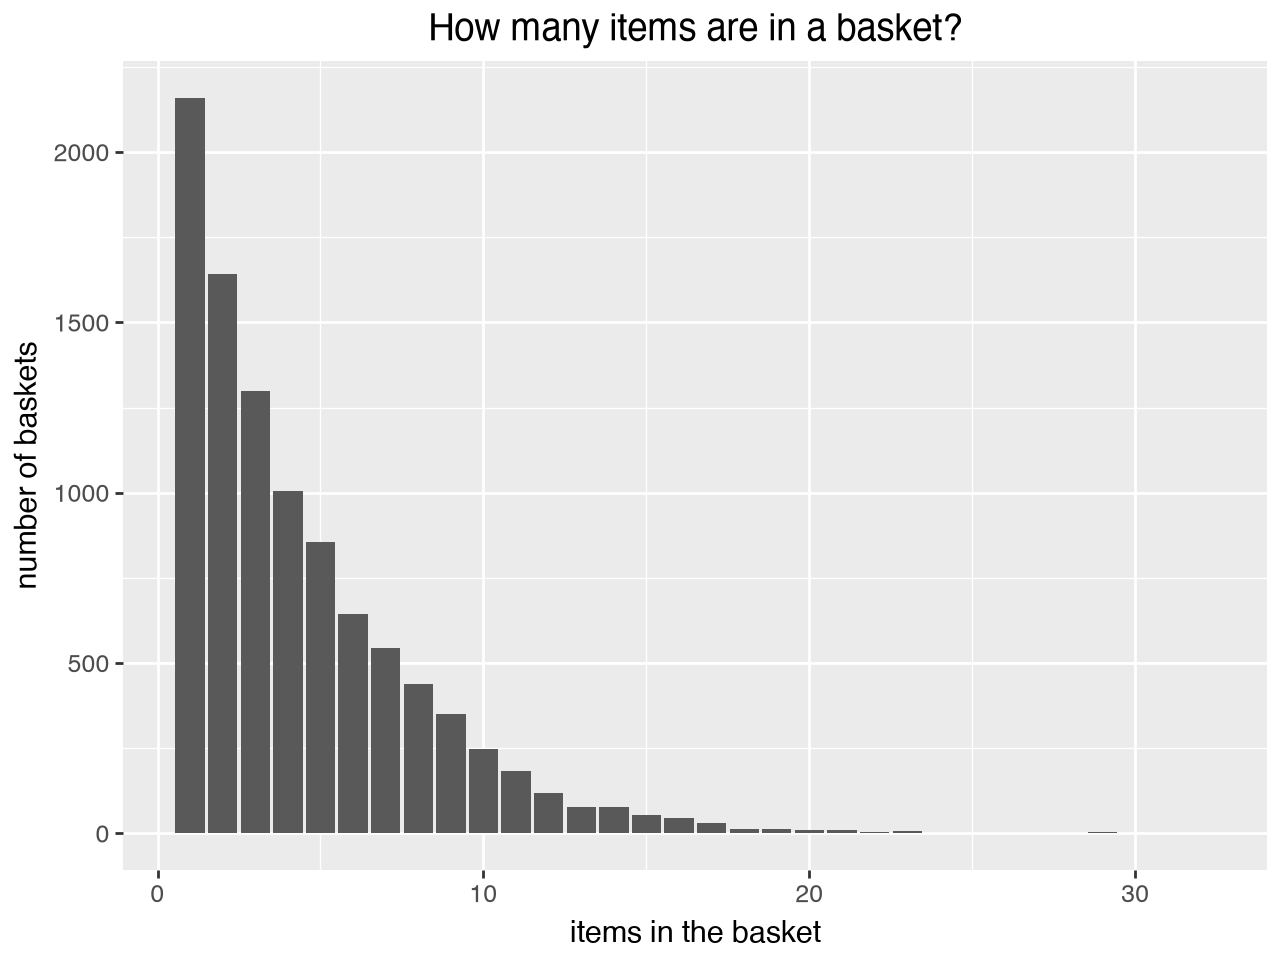

In [9]:
size_df = size_counts.reset_index()
size_df.columns = ["n_items", "baskets"]

(ggplot(size_df, aes(x="n_items", y="baskets"))
 + geom_col()
 + labs(title="How many items are in a basket?", x="items in the basket", y="number of baskets"))

**What the code does.** `describe()` gives the five-number summary and the mean; `value_counts().sort_index()`
counts baskets of each size in size order; `geom_col` draws one bar per size.

**Expected output.** Mean **4.41** items, median **3**, quartiles 2 and 6, minimum 1, maximum **32**. The
distribution is strongly right-skewed: **2,159 baskets (22 %) contain a single item**, 1,643 have two, 1,299
three — more than half of all baskets have three items or fewer — and only a handful exceed 25.

**Points to make.** A single-item basket can never support a rule, and a two-item basket supports exactly one
pair. So the 43,367 item-rows carry far less *co-occurrence* evidence than the raw count suggests, which is why
support thresholds in this data end up around 1 %.

**Common mistakes.** `geom_histogram` on an integer variable with default bins — bars straddle the integers;
`geom_bar(stat="count")` on `basket_sizes` directly also works. Using `basket.describe()` (169 columns) instead of
`basket_sizes.describe()`.

4. Compute the support of every item, sorted from largest to smallest, and store it in `item_support`. Then make a horizontal bar chart of the 15 most popular items.

### Solution 4 — item support and the 15 most popular items

**Approach.** Support of an item = share of baskets containing it = the mean of its boolean column. Sort, take
the top 15, and draw a horizontal bar chart.

In [10]:
item_support = basket.mean().sort_values(ascending=False)
item_support.head(15).round(3)

item
whole milk          0.256
other vegetables    0.193
rolls/buns          0.184
soda                0.174
yogurt              0.140
bottled water       0.111
root vegetables     0.109
tropical fruit      0.105
shopping bags       0.099
sausage             0.094
pastry              0.089
citrus fruit        0.083
bottled beer        0.081
newspapers          0.080
canned beer         0.078
dtype: float64

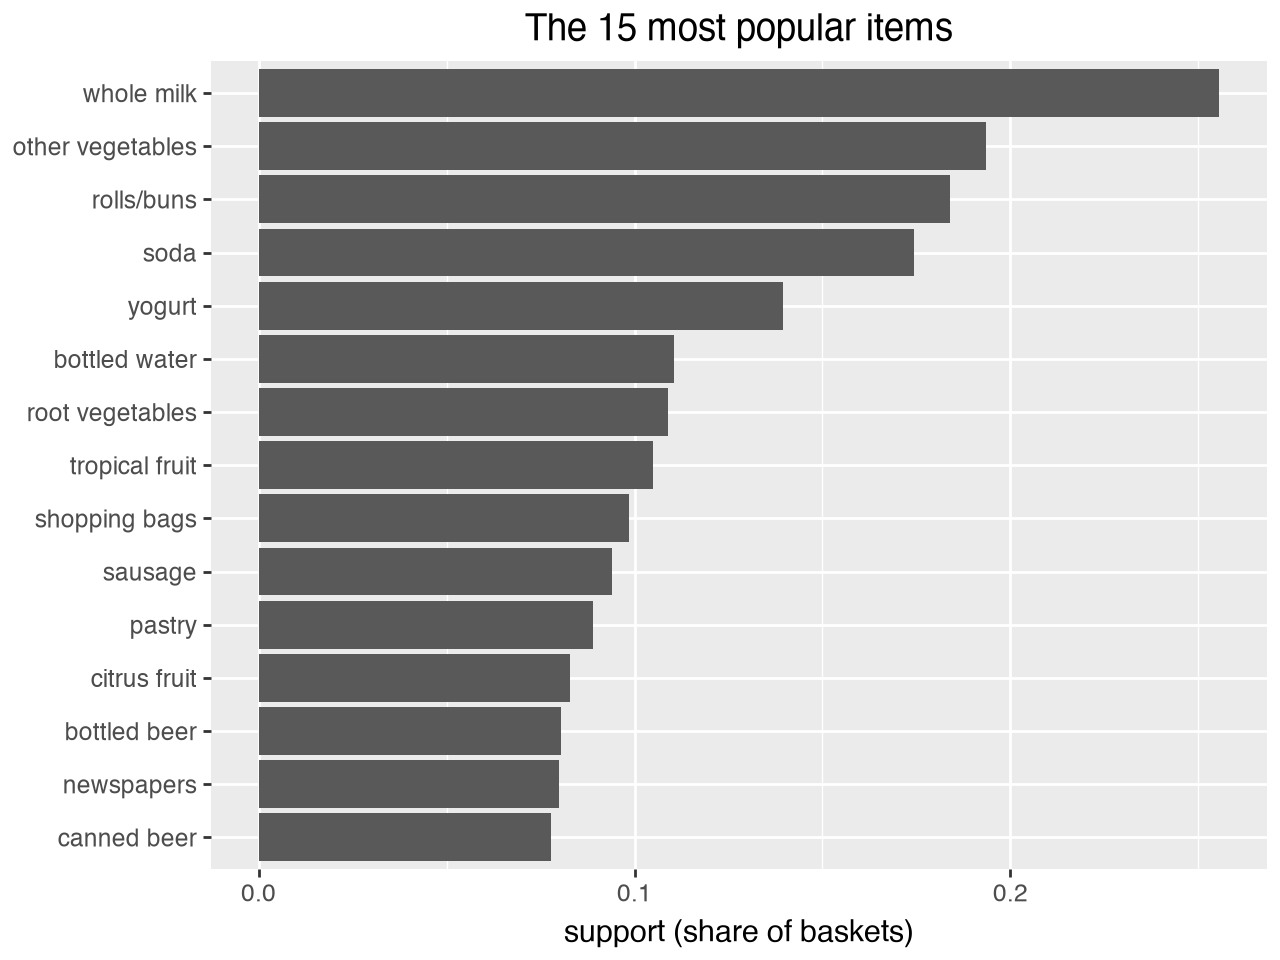

In [11]:
top15 = item_support.head(15).reset_index()
top15.columns = ["item", "support"]
top15["item"] = pd.Categorical(top15["item"], categories=top15["item"][::-1])   # most popular at the top after coord_flip

(ggplot(top15, aes(x="item", y="support"))
 + geom_col()
 + coord_flip()
 + labs(title="The 15 most popular items", x="", y="support (share of baskets)"))

**What the code does.**
- `basket.mean()` averages each column; `True` counts as 1, so the mean is the share of baskets with the item.
- `pd.Categorical(..., categories=top15["item"][::-1])` fixes the plotting order (plotnine otherwise sorts the
  axis alphabetically); reversing it puts the most popular item at the **top** once `coord_flip()` turns the bars
  sideways.

**Expected output.** whole milk **0.256**, other vegetables 0.193, rolls/buns 0.184, soda 0.174, yogurt 0.140,
bottled water 0.111, root vegetables 0.109, tropical fruit 0.105, shopping bags 0.099, sausage 0.094, pastry
0.089, citrus fruit 0.083, bottled beer 0.081, newspapers 0.080, canned beer 0.078.

**Common mistakes.**
- `basket.sum()` — counts, not shares; divide by `len(basket)` or use `.mean()`.
- `long["item"].value_counts(normalize=True)` — the share of **item-rows**, not of baskets (whole milk would be
  5.8 %, not 25.6 %). Support is always "out of baskets".
- Bars in alphabetical order because the categorical order was not set.

5. Consider the basket sizes and the item supports. Which item is most popular, and in what percentage of baskets does it appear? Which items are most common? What does this suggest about the "popular items co-occur just by chance" problem discussed in the reading?

**Answer (part 5).** The most popular item is **whole milk**, in **25.6 %** of all baskets (2,513 of 9,835). The
next most common are other vegetables (19.3 %), rolls/buns (18.4 %), soda (17.4 %), and yogurt (14.0 %); after
that support drops quickly — the median item is in about 1 % of baskets and 81 of the 169 items are below 1 %.

Put that next to the basket sizes (median 3 items, 22 % single-item baskets): most baskets are small, and a
quarter of them contain whole milk regardless of what else is in them. So **any** item will show up with whole
milk fairly often *purely because whole milk is everywhere* — the rule {X} → {whole milk} will have a confidence
around 25 % even if X has nothing to do with milk. That is exactly the "popular items co-occur just by chance"
problem: confidence inherits the consequent's popularity. Lift divides it back out, which is why the rest of this
activity keeps asking for lift alongside confidence.

6. Consider the rule **{yogurt} → {whole milk}**. Compute and interpret the confidence of this rule.


### Solution 6 — confidence of {yogurt} → {whole milk}

**Approach.** confidence = support(yogurt **and** whole milk) ÷ support(yogurt): of the baskets with yogurt, what
share also contain whole milk?

In [12]:
has_yogurt = basket["yogurt"]
has_milk = basket["whole milk"]

support_yogurt = has_yogurt.mean()
support_milk = has_milk.mean()
support_both = (has_yogurt & has_milk).mean()

confidence_y_m = support_both / support_yogurt
print(f"support(yogurt) = {support_yogurt:.4f}   support(whole milk) = {support_milk:.4f}   support(both) = {support_both:.4f}")
print(f"confidence(yogurt -> whole milk) = {confidence_y_m:.4f}")

support(yogurt) = 0.1395   support(whole milk) = 0.2555   support(both) = 0.0560
confidence(yogurt -> whole milk) = 0.4016


**What the code does.** `has_yogurt & has_milk` is `True` only for baskets with both items (`&` is the
element-wise *and* for boolean Series); its mean is the support of the pair. Dividing by the support of the
antecedent gives the confidence — equivalently, `has_milk[has_yogurt].mean()`.

**Expected output.** support(yogurt) 0.1395, support(whole milk) 0.2555, support(both) **0.0560**;
**confidence = 0.4016**.

**Interpretation.** About **40 % of the baskets that contain yogurt also contain whole milk.** On its own that
sounds strong — but compare it with the 25.6 % of *all* baskets that contain whole milk (part 7).

**Common mistakes.** Using `and` instead of `&` → the ambiguous-truth-value `ValueError`. Dividing by
support(whole milk) instead of support(yogurt) — that is the confidence of the reverse rule (part 8).

7. Compute and interpret the **lift** of {yogurt} → {whole milk}.

### Solution 7 — lift of {yogurt} → {whole milk}

**Approach.** lift = support(both) ÷ [support(yogurt) × support(whole milk)]: how many times more often do the two
appear together than if they were bought independently? Equivalently, confidence ÷ support(whole milk).

In [13]:
lift_y_m = support_both / (support_yogurt * support_milk)
print(f"lift(yogurt -> whole milk) = {lift_y_m:.4f}")
print(f"check: confidence / support(whole milk) = {confidence_y_m / support_milk:.4f}")

lift(yogurt -> whole milk) = 1.5717
check: confidence / support(whole milk) = 1.5717


**What the code does.** If yogurt and milk were independent, the share of baskets with both would be
0.1395 × 0.2555 = 0.0356. The observed share is 0.0560; the ratio is the lift.

**Expected output.** **lift = 1.5717** (both ways).

**Interpretation.** Baskets with yogurt contain whole milk about **1.57 times as often as baskets in general**
(40.2 % versus 25.6 %). Lift above 1 means the two items are positively associated — yogurt does carry
information about milk, over and above milk's popularity.

**Common mistakes.** Reporting confidence as if it were lift ("yogurt buyers are 40 % more likely…"): 40 % is the
share, 57 % *more* likely is the lift − 1. Computing support(both) ÷ support(yogurt) ÷ support(milk) with
parentheses in the wrong place.

8. Now compute and interpret the confidence and lift for the rule {whole milk} → {yogurt}.

### Solution 8 — the reverse rule {whole milk} → {yogurt}

**Approach.** Same support of the pair; the confidence now divides by support(whole milk). The lift formula is
symmetric, so it does not change.

In [14]:
confidence_m_y = support_both / support_milk
lift_m_y = support_both / (support_milk * support_yogurt)
print(f"confidence(whole milk -> yogurt) = {confidence_m_y:.4f}")
print(f"lift(whole milk -> yogurt)       = {lift_m_y:.4f}")

confidence(whole milk -> yogurt) = 0.2193
lift(whole milk -> yogurt)       = 1.5717


**Expected output.** confidence **0.2193**, lift **1.5717**.

**Interpretation.** Only **22 % of whole-milk baskets contain yogurt** (because many milk baskets are small and
yogurt is less common than milk), yet the **lift is identical**: 22 % is still 1.57 times yogurt's overall
support of 14 %. Confidence depends on the direction of the rule; lift does not. For "what should we put next
to yogurt?" the direction matters (part 19).

**Common mistakes.** Expecting the lift to change; thinking the lower confidence means the association is weaker
in this direction — it is the same association, described from the other side.

9. Write two functions.

- `support(items, onehot)`: returns the share of baskets that contain **all** of the items in the list `items`.
- `rule_metrics(antecedent, consequent, onehot)`: returns a Pandas Series with the `support`, `confidence`, and `lift` of the rule `antecedent -> consequent`. Both `antecedent` and `consequent` are *lists* of items.

Test the functions on `["yogurt"]` → `["whole milk"]`. The values should match the ones you computed earlier.

### Solution 9 — `support()` and `rule_metrics()`

**Approach.** Package parts 6–8 into functions so they can be reused (Week 6). `support` handles a **list** of
items with `.all(axis=1)` ("every one of these columns is `True`"). `rule_metrics` calls `support` three times and
returns the three numbers as a Series so `apply` can stack them into a data frame (part 11).

In [15]:
def support(items, onehot):
    """
    Share of baskets that contain ALL of the items.

    Parameters
    ----------
    items : list of str
      Item names (columns of onehot).
    onehot : DataFrame of bool
      One row per basket, one column per item.

    Returns
    -------
    float
    """
    return onehot[items].all(axis=1).mean()


def rule_metrics(antecedent, consequent, onehot):
    """
    Support, confidence, and lift of the rule antecedent -> consequent.

    Parameters
    ----------
    antecedent, consequent : list of str
    onehot : DataFrame of bool

    Returns
    -------
    Series with index ["support", "confidence", "lift"]
    """
    s_both = support(antecedent + consequent, onehot)
    s_ante = support(antecedent, onehot)
    s_cons = support(consequent, onehot)
    return pd.Series({"support": s_both,
                      "confidence": s_both / s_ante,
                      "lift": s_both / (s_ante * s_cons)})

In [16]:
print(support(["yogurt"], basket), support(["whole milk"], basket), support(["yogurt", "whole milk"], basket))
rule_metrics(["yogurt"], ["whole milk"], basket)

0.13950177935943062 0.25551601423487547 0.05602440264361973


support       0.056024
confidence    0.401603
lift          1.571735
dtype: float64

**What the code does.**
- `onehot[items]` selects the listed columns (a list inside the brackets); `.all(axis=1)` is one `True`/`False`
  per basket; `.mean()` is the share. For a one-item list it reduces to the column mean.
- `antecedent + consequent` concatenates the two lists — the itemset of the whole rule.
- Returning a **Series** (not a tuple or dict) is what lets `Series.apply` in part 11 produce a tidy table.

**Expected output.** `0.1395 0.2555 0.0560` and the Series support **0.0560**, confidence **0.4016**, lift
**1.5717** — identical to parts 6–7.

**Common mistakes.**
- `onehot[items].mean()` without `.all(axis=1)` → one support **per item**, not of the set.
- Passing strings instead of lists (`support("yogurt", basket)`) → `onehot["yogurt"]` is a Series and `.all(axis=1)`
  raises `ValueError: No axis named 1 for object type Series`. The docstring says *list*; `isinstance` checks
  from PA 6.1 would make the message friendlier.
- `antecedent & consequent` or `antecedent.append(consequent)` to combine the lists — the first is a `TypeError`,
  the second nests a list inside a list.

10. Whole milk is in about a quarter of all baskets. Consider the rules `{X} → {whole milk}` for the five antecedents `X` in the next cell. Before running anything, predict: for which of these will the lift be **above 1**? For which might the confidence look decent but the lift be **close to or below 1**? Just think about this before proceeding.

**Instructor note (part 10, predictions).** Whole milk is in 25.6 % of baskets, so every rule {X} → {whole milk}
starts from a confidence "floor" of about 0.26 if X carries no information. Reasonable predictions: **yogurt** and
**other vegetables** are fresh-food staples bought on the same trips as milk → lift clearly above 1; **rolls/buns**
and **bottled water** are everyday items → lift modestly above 1; **soda** is a drink bought *instead of* milk or on
snack runs → confidence may look fine (~0.23) but lift near or **below 1**. Part 11 checks these.

In [17]:
antecedents = pd.Series(["yogurt", "rolls/buns", "bottled water", "soda", "other vegetables"])

11. Compute the support, confidence, and lift of `{X} → {whole milk}` for each of the five antecedents above, and display the results sorted by lift (largest first). Compare to your predictions. Hint: Use `apply` with `lambda` on the Series of antecedents.


### Solution 11 — {X} → {whole milk} for five antecedents

**Approach.** `rule_metrics` handles one rule; `apply` with a lambda runs it for every X in the Series and stacks the
returned Series into a data frame. Label the rows with the antecedents and sort by lift.

In [18]:
milk_rules = antecedents.apply(lambda x: rule_metrics([x], ["whole milk"], basket))
milk_rules.index = antecedents
milk_rules.sort_values("lift", ascending=False).round(4)

,support,confidence,lift
yogurt,0.0560,0.4016,1.5717
other vegetables,0.0748,0.3868,1.5136
bottled water,0.0344,0.3109,1.2169
rolls/buns,0.0566,0.3079,1.2050
soda,0.0401,0.2297,0.8991


**What the code does.** `Series.apply(f)` calls `f` once per element; because `f` returns a Series, the results
line up as rows of a DataFrame with the Series' index as columns. `[x]` wraps the string in a list, as the
function expects. Setting `.index = antecedents` replaces the 0–4 labels with the item names.

**Expected output (sorted by lift).**

| X | support | confidence | lift |
|---|---|---|---|
| yogurt | 0.0560 | 0.4016 | **1.5717** |
| other vegetables | 0.0748 | 0.3868 | **1.5136** |
| bottled water | 0.0344 | 0.3109 | 1.2169 |
| rolls/buns | 0.0566 | 0.3079 | 1.2050 |
| soda | 0.0401 | 0.2297 | **0.8991** |

**Compare with the predictions.** Yogurt and other vegetables lead; rolls/buns and bottled water are mildly
positive; **soda's lift is below 1**: baskets with soda contain whole milk *less* often (23 %) than baskets in
general (25.6 %). Its confidence of 0.23 would look acceptable on its own — the clearest illustration of why
confidence alone misleads.

**Common mistakes.**
- `rule_metrics(antecedents, ["whole milk"], basket)` with the whole Series → the support of all five items
  *together* (0), then a division by zero or `nan`.
- `antecedents.apply(rule_metrics, ...)` without the lambda → `TypeError: rule_metrics() missing 2 required
  positional arguments` (the Topic 6.1 / PA 6.2 pattern: the lambda adapts the arguments).
- Forgetting `[x]` → the string error from part 9.

12. Run `apriori` on `basket` with `min_support=0.01` and store the result in `frequent_itemsets`. Then add a column `n_items` giving the number of items in each itemset.

### Solution 12 — frequent itemsets with `apriori`

**Approach.** `apriori` finds every set of items whose support is at least `min_support`. `use_colnames=True`
labels the itemsets with item names instead of column numbers. The itemsets are frozensets, so `len` gives the
number of items.

In [19]:
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
frequent_itemsets["n_items"] = frequent_itemsets["itemsets"].apply(len)

print(frequent_itemsets.shape)
print(frequent_itemsets["n_items"].value_counts().sort_index())
frequent_itemsets.sort_values("support", ascending=False).head(8)

(333, 3)
n_items
1     88
2    213
3     32
Name: count, dtype: int64


,support,itemsets,n_items
86,0.255516,frozenset({whole milk}),1
55,0.193493,frozenset({other vegetables}),1
66,0.183935,frozenset({rolls/buns}),1
75,0.174377,frozenset({soda}),1
87,0.139502,frozenset({yogurt}),1
6,0.110524,frozenset({bottled water}),1
67,0.108998,frozenset({root vegetables}),1
81,0.104931,frozenset({tropical fruit}),1


**What the code does.** With `min_support=0.01` an itemset must appear in at least 1 % of baskets (≈ 99 baskets).
Apriori works level by level — single items, then pairs built from frequent single items, then triples — which is
why it is fast even with 169 items. `.apply(len)` counts the members of each frozenset.

**Expected output.** **333 frequent itemsets: 88 single items, 213 pairs, 32 triples**; no itemset of four or more
reaches 1 %. The most frequent itemsets are the popular single items (whole milk 0.256, …); the most frequent pair
is {other vegetables, whole milk} at 0.075.

**Common mistakes.**
- Omitting `use_colnames=True` → itemsets shown as column positions like `{18, 108}`.
- A `min_support` typed as `1` or `10` (thinking "percent") → an empty table; it is a share between 0 and 1.
- Passing the integer crosstab (part 1 without `> 0`) → a `DeprecationWarning` about non-bool input, and with
  counts above 1 wrong supports.
- `len(frequent_itemsets["itemsets"])` → 333 (number of itemsets), not the size of each.

13. Generate the rules with `make_rules`, keeping rules with confidence of at least 0.20. Store them in `rules` and print how many there are.

### Solution 13 — rules with `make_rules`

**Approach.** `make_rules` is the reading's helper around mlxtend's `association_rules`: from the frequent
itemsets, form every rule *antecedent → consequent* and keep those whose confidence is at least the threshold.
It is defined here so the notebook is self-contained.

In [20]:
def make_rules(frequent_itemsets, min_confidence):
    """Association rules from frequent itemsets, keeping those with confidence >= min_confidence."""
    return association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)


rules = make_rules(frequent_itemsets, 0.20)
print(len(rules), "rules")
rules.columns.tolist()

234 rules


['antecedents',
 'consequents',
 'antecedent support',
 'consequent support',
 'support',
 'confidence',
 'lift',
 'representativity',
 'leverage',
 'conviction',
 'zhangs_metric',
 'jaccard',
 'certainty',
 'kulczynski']

**What the code does.** For each frequent itemset with at least two items, `association_rules` tries every split
into antecedent and consequent, computes the metrics from the supports already in `frequent_itemsets`, and keeps
the rules passing `metric="confidence", min_threshold=0.20`. The result has the frozenset columns `antecedents`
and `consequents`, then `antecedent support`, `consequent support`, `support`, `confidence`, `lift`, and several
further metrics (leverage, conviction, …) we do not use.

**Expected output.** **234 rules.**

**Common mistakes.**
- Calling `make_rules` on `basket` instead of `frequent_itemsets` → a `KeyError`/`ValueError` about missing
  `support`/`itemsets` columns.
- Reading `min_threshold` as a support threshold — it applies to whichever `metric` is named.
- A threshold of `20` → zero rules.

14. Make the rules easier to read. Create a copy `rules_display` of `rules` and add three columns:

- `antecedent`: the antecedent items as text, e.g. `"tropical fruit, yogurt"`
- `consequent`: the consequent items as text
- `transactions`: the number of baskets that contain the whole rule (support times the number of baskets, rounded to an integer)

Then display the columns `antecedent`, `consequent`, `support`, `confidence`, `lift`, `transactions` for the first 8 rules.

### Solution 14 — readable rules

**Approach.** Copy, then add three columns: the frozensets joined into text, and the number of baskets behind
each rule (support × number of baskets).

In [21]:
rules_display = rules.copy()
rules_display["antecedent"] = rules_display["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules_display["consequent"] = rules_display["consequents"].apply(lambda s: ", ".join(sorted(s)))
rules_display["transactions"] = (rules_display["support"] * len(basket)).round().astype(int)

show = ["antecedent", "consequent", "support", "confidence", "lift", "transactions"]
rules_display[show].head(8).round(3)

,antecedent,consequent,support,confidence,lift,transactions
0,beef,other vegetables,0.020,0.376,1.943,194
1,beef,rolls/buns,0.014,0.260,1.412,134
2,beef,root vegetables,0.017,0.331,3.040,171
3,beef,whole milk,0.021,0.405,1.585,209
4,beef,yogurt,0.012,0.223,1.598,115
5,berries,other vegetables,0.010,0.309,1.596,101
6,berries,whole milk,0.012,0.355,1.388,116
7,berries,yogurt,0.011,0.318,2.280,104


**What the code does.** `", ".join(sorted(s))` turns a frozenset like `frozenset({'yogurt', 'tropical fruit'})`
into `"tropical fruit, yogurt"` (sorting makes the text deterministic). `support × 9835` is the number of baskets
containing every item of the rule; `.round().astype(int)` makes it a whole number.

**Expected output.** The first eight rules all have the antecedent **beef** or **berries**: beef → other
vegetables (support 0.020, confidence 0.376, lift 1.94, 194 baskets), beef → rolls/buns, beef → root vegetables
(lift **3.04**, 171 baskets), beef → whole milk, beef → yogurt, berries → other vegetables, berries → whole milk,
berries → yogurt (lift 2.28, 104 baskets).

**Common mistakes.**
- `str(s)` instead of joining → text like `frozenset({'beef'})`.
- `", ".join(s)` without `sorted` works but orders items arbitrarily.
- Forgetting `.copy()` and then being surprised that `rules` gained columns (harmless here, but the question asks
  for a copy).
- `rules["support"] * 9835` typed as a literal — use `len(basket)` so the code survives a different data set.

15. Show the 10 rules with the highest **confidence**. What do the highest-confidence rules have in common? Why is confidence alone a poor guide here?

### Solution 15 — the 10 highest-confidence rules

In [22]:
rules_display.sort_values("confidence", ascending=False)[show].head(10).round(3)

,antecedent,consequent,support,confidence,lift,transactions
156,"citrus fruit, root vegetables",other vegetables,0.010,0.586,3.030,102
184,"root vegetables, tropical fruit",other vegetables,0.012,0.585,3.021,121
163,"curd, yogurt",whole milk,0.010,0.582,2.279,99
154,"butter, other vegetables",whole milk,0.011,0.574,2.245,113
222,"root vegetables, tropical fruit",whole milk,0.012,0.570,2.231,118
224,"root vegetables, yogurt",whole milk,0.015,0.563,2.203,143
166,"domestic eggs, other vegetables",whole milk,0.012,0.553,2.162,121
232,"whipped/sour cream, yogurt",whole milk,0.011,0.525,2.053,107
213,"rolls/buns, root vegetables",whole milk,0.013,0.523,2.047,125
172,"other vegetables, pip fruit",whole milk,0.014,0.518,2.025,133


**What they have in common.** Eight of the ten have the consequent **whole milk**, the other two **other
vegetables** — the two most popular items in the store. Every antecedent is a *pair* of fresh/dairy items
(root vegetables + tropical fruit, curd + yogurt, butter + other vegetables, …), and the top confidence is only
**0.586**: even the best rule is right a little over half the time. Each rule rests on roughly 100–140 baskets
(support 1.0–1.5 %).

**Why confidence alone is a poor guide.** Confidence is bounded below by the consequent's own support, so
popular consequents float to the top whatever the antecedent is. These rules say "people who buy two fresh
items also buy milk", which is close to "people buy milk". The lift column (2.0–3.0 here) is what shows the
antecedent adds information — and part 16 shows that sorting by lift brings up different consequents entirely.

**Common mistakes.** Sorting `rules` (frozensets) rather than `rules_display`; `ascending=True` by default →
the ten *lowest*; `nlargest(10, "confidence")` is a fine alternative.

16. Show the 10 rules with the highest **lift**. Compare this list with the highest-confidence list. What kinds of products appear now? Look at the `support` and `transactions` columns: how much evidence is each of these rules based on?

### Solution 16 — the 10 highest-lift rules

In [23]:
rules_display.sort_values("lift", ascending=False)[show].head(10).round(3)

,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010,0.359,3.295,102
208,"other vegetables, yogurt",whipped/sour cream,0.010,0.234,3.267,100
185,"other vegetables, tropical fruit",root vegetables,0.012,0.343,3.145,121
2,beef,root vegetables,0.017,0.331,3.040,171
156,"citrus fruit, root vegetables",other vegetables,0.010,0.586,3.030,102
184,"root vegetables, tropical fruit",other vegetables,0.012,0.585,3.021,121
190,root vegetables,"other vegetables, whole milk",0.023,0.213,2.842,228
189,"other vegetables, whole milk",root vegetables,0.023,0.310,2.842,228
155,butter,"other vegetables, whole milk",0.011,0.207,2.771,113
164,"curd, whole milk",yogurt,0.010,0.385,2.761,99


**Compared with the confidence list.** The consequents change: **root vegetables**, **whipped/sour cream**,
**yogurt**, and the pair {other vegetables, whole milk} replace plain whole milk. The top rules are produce
pairings — {citrus fruit, other vegetables} → root vegetables (lift **3.30**), {other vegetables, tropical fruit}
→ root vegetables (3.15), **beef → root vegetables (3.04)** — plus dairy pairings such as {curd, whole milk} →
yogurt (2.76). These are "cooking a meal" and "dairy aisle" baskets: items that genuinely travel together, not
items that are simply popular.

**How much evidence?** Look at `support` and `transactions`: most of these rules sit at **1.0–1.2 % support, about
100–120 baskets**; the strongest-evidence rules on the list are {other vegetables, whole milk} ↔ root vegetables
(**228 baskets**) and beef → root vegetables (171). A lift of 3.3 built on 102 baskets out of 9,835 is a real but
modest pattern — and some rules have confidence as low as 0.21–0.23 (e.g. → whipped/sour cream), so a high lift
can describe a rule that is still usually wrong. That is why part 17 filters on **both** confidence and lift.

**Common mistakes.** Treating lift as a probability; ignoring that the two rules with 228 transactions are the same
itemset read in two directions (identical lift, different confidence — part 8 again).

17. Create `interesting_rules`: the rules with **confidence of at least 0.30 and lift of at least 1.5**, sorted by lift (largest first).


### Solution 17 — `interesting_rules`

**Approach.** Combine two boolean filters with `&`, then sort by lift.

In [24]:
interesting_rules = (rules_display[(rules_display["confidence"] >= 0.30) & (rules_display["lift"] >= 1.5)]
                     .sort_values("lift", ascending=False))

print(len(interesting_rules), "rules")
interesting_rules[show].head(12).round(3)

108 rules


,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010,0.359,3.295,102
185,"other vegetables, tropical fruit",root vegetables,0.012,0.343,3.145,121
2,beef,root vegetables,0.017,0.331,3.040,171
156,"citrus fruit, root vegetables",other vegetables,0.010,0.586,3.030,102
184,"root vegetables, tropical fruit",other vegetables,0.012,0.585,3.021,121
189,"other vegetables, whole milk",root vegetables,0.023,0.310,2.842,228
164,"curd, whole milk",yogurt,0.010,0.385,2.761,99
175,"rolls/buns, root vegetables",other vegetables,0.012,0.502,2.595,120
191,"root vegetables, yogurt",other vegetables,0.013,0.500,2.584,127
231,"tropical fruit, whole milk",yogurt,0.015,0.358,2.568,149


**What the code does.** Each comparison produces a boolean Series; `&` combines them element-wise (parentheses are
required around each comparison); the result indexes the rows to keep.

**Expected output.** **108 rules.** The top of the list: {citrus fruit, other vegetables} → root vegetables
(0.359, 3.30), {other vegetables, tropical fruit} → root vegetables (0.343, 3.15), beef → root vegetables
(0.331, 3.04), {citrus fruit, root vegetables} → other vegetables (0.586, 3.03), {root vegetables, tropical fruit}
→ other vegetables (0.585, 3.02), {other vegetables, whole milk} → root vegetables (0.310, 2.84, 228 baskets), {curd,
whole milk} → yogurt (0.385, 2.76), … Consequents are dominated by other vegetables (44 rules) and whole milk (49),
with yogurt (9), root vegetables (4), and rolls/buns (2).

**Common mistakes.** `and` instead of `&`; missing parentheses → `TypeError: unsupported operand type(s) for &`
because `0.30 & rules["lift"]` is evaluated first; filtering `rules` and then losing the text columns.

18. Choose **one** rule from the table and interpret its **support**, **confidence**, and **lift** with numbers, as you did for {yogurt} → {whole milk}.

**Answer (part 18) — one rule interpreted: {beef} → {root vegetables}.**

- **Support 0.017** — 1.7 % of all baskets, **171 baskets**, contain both beef and root vegetables. That is the
  evidence the rule rests on: not huge, but well above the 1 % floor.
- **Confidence 0.331** — of the baskets that contain beef, **33 % also contain root vegetables**. A shopper buying
  beef has about a one-in-three chance of also buying root vegetables (carrots, onions, potatoes — the makings of
  a stew or roast).
- **Lift 3.04** — root vegetables are in 10.9 % of baskets overall, so beef buyers pick them up **about three times
  as often as shoppers in general** (33 % vs 11 %). This is a strong, positive association, not a popularity effect:
  root vegetables are not an especially common item, so the confidence is *earned*.

Taken together: a genuine "cooking a meal" pattern with a moderate amount of evidence — a sensible candidate for
placing a root-vegetable display near the meat counter.

19. The manager wants to **increase sales of yogurt**. Which products should the store link to yogurt (shelf placement, a joint promotion, a recommendation)?

### Solution 19 — increasing yogurt sales

**Approach.** To sell more yogurt, find the products whose buyers are unusually likely to *also* buy yogurt:
rules with **yogurt as the consequent**, ranked by lift, with enough support to matter. (Rules with yogurt as
the antecedent say what yogurt buyers add — useful for a different question.)

In [25]:
to_yogurt = (rules_display[rules_display["consequent"] == "yogurt"]
             .sort_values("lift", ascending=False))

print(len(to_yogurt), "rules point to yogurt")
to_yogurt[show].head(12).round(3)

32 rules point to yogurt


,antecedent,consequent,support,confidence,lift,transactions
164,"curd, whole milk",yogurt,0.010,0.385,2.761,99
231,"tropical fruit, whole milk",yogurt,0.015,0.358,2.568,149
209,"other vegetables, whipped/sour cream",yogurt,0.010,0.352,2.524,100
202,"other vegetables, tropical fruit",yogurt,0.012,0.343,2.457,121
233,"whipped/sour cream, whole milk",yogurt,0.011,0.338,2.420,107
161,"citrus fruit, whole milk",yogurt,0.010,0.337,2.413,101
47,curd,yogurt,0.017,0.324,2.326,170
7,berries,yogurt,0.011,0.318,2.280,104
43,cream cheese,yogurt,0.012,0.313,2.242,122
212,"other vegetables, whole milk",yogurt,0.022,0.298,2.133,219


In [26]:
# Single-item antecedents only — the easiest to act on (one product to pair with yogurt)
single = to_yogurt[~to_yogurt["antecedent"].str.contains(",")]
single[show].round(3)

,antecedent,consequent,support,confidence,lift,transactions
47,curd,yogurt,0.017,0.324,2.326,170
7,berries,yogurt,0.011,0.318,2.280,104
43,cream cheese,yogurt,0.012,0.313,2.242,122
147,whipped/sour cream,yogurt,0.021,0.289,2.074,204
144,tropical fruit,yogurt,0.029,0.279,2.000,288
23,butter,yogurt,0.015,0.264,1.894,144
38,citrus fruit,yogurt,0.022,0.262,1.876,213
67,fruit/vegetable juice,yogurt,0.019,0.259,1.855,184
62,frozen vegetables,yogurt,0.012,0.258,1.849,122
78,margarine,yogurt,0.014,0.243,1.742,140


**What the code does.** `rules_display["consequent"] == "yogurt"` keeps rules whose *whole* consequent is yogurt;
`~ ... .str.contains(",")` keeps antecedents without a comma — single items.

**Expected output.** 32 rules point to yogurt. Single-item antecedents, by lift: **curd** (confidence 0.324, lift
2.33, 170 baskets), **berries** (0.318, 2.28, 104), **cream cheese** (0.313, 2.24, 122), **whipped/sour cream**
(0.289, 2.07, 204), **tropical fruit** (0.279, 2.00, **288 baskets**), butter (1.89), citrus fruit (1.88, 213),
fruit/vegetable juice (1.86), … down to whole milk (0.219, lift 1.57, but **551 baskets**) and bottled water
(1.49). Two-item antecedents go higher — {curd, whole milk} → yogurt lift 2.76, {tropical fruit, whole milk} →
yogurt 2.57 (149 baskets) — but are harder to act on.

**Recommendation.**
1. **The dairy case: curd, cream cheese, whipped/sour cream, butter.** Lift 1.9–2.3: their buyers are about twice as
   likely as average to buy yogurt. Shelve yogurt beside them (or cross-promote) — the natural "dairy basket".
2. **Fresh fruit: tropical fruit, berries, citrus fruit.** Lift 1.9–2.3 with the largest evidence among the
   high-lift items (tropical fruit 288 baskets, citrus 213). A "fruit + yogurt" breakfast promotion or a yogurt
   cooler at the fruit display.
3. **Whole milk** is the biggest *absolute* opportunity (551 shared baskets) but the weakest lift (1.57); a
   recommendation there mostly reaches people already likely to buy yogurt. Fine for a coupon printed with milk,
   weak as a "discovery" link.

Avoid items with lift near 1 (soda, shopping bags): they share baskets with yogurt only because they are common.

**Common mistakes.** Using rules with yogurt as the **antecedent** ("what do yogurt buyers also buy?") — those tell
you what to sell *to* yogurt buyers, not how to bring new buyers to yogurt. Ranking by confidence (whole milk →
yogurt would win on transactions but barely beats chance). Ignoring support and recommending a 99-basket rule as
the headline.

---
## References and attribution


- Hahsler, M., Gr&uuml;n, B., and Hornik, K. (2005). arules: A computational environment for mining association rules and frequent item sets. *Journal of Statistical Software*, 14(15). (The R package that distributes the data.)
- Data copy: GitHub repository `stedy/Machine-Learning-with-R-datasets` (`groceries.csv`), the data used in Lantz, B., *Machine Learning with R*.
- Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software*, 3(24), 638. <https://doi.org/10.21105/joss.00638>


**Preparation of this notebook:** drafted with the assistance of generative AI tools (ChatGPT and Claude).